#### 1) Setup & Data Loading

* Importe the Palmer's Penguins dataset from Kaggle

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import kagglehub
os.environ["KAGGLE_API_TOKEN"] = "KGAT_a5aabe7b7dea0a39996ec1da9c679bca"
path = kagglehub.dataset_download("samybaladram/palmers-penguin-dataset-extended")
print("Path to dataset files:", path)

100%|██████████| 41.5k/41.5k [00:00<00:00, 662kB/s]

Extracting files...
Path to dataset files: C:\Users\lyj19\.cache\kagglehub\datasets\samybaladram\palmers-penguin-dataset-extended\versions\2


In [2]:
df = pd.read_csv(os.path.join(path, "palmerpenguins_original.csv"))
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


**Q1** (check): How many rows and columns does the dataset have? Which columns are numeric vs categorical?

In [5]:
print("Shape (rows, cols):", df.shape)
display(df.dtypes)

numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

print("\nNumeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Shape (rows, cols): (344, 8)


species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
year                   int64
dtype: object


Numeric columns: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year']
Categorical columns: ['species', 'island', 'sex']


#### 2) Basic EDA (Exploratory Data Analysis)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,female,2007
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
species,344,3,Adelie,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
island,344,3,Biscoe,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bill_length_mm,342.0,NaN,NaN,NaN,43.92193,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,NaN,NaN,NaN,17.15117,1.974793,13.1,15.6,17.3,18.7,21.5
flipper_length_mm,342.0,NaN,NaN,NaN,200.915205,14.061714,172.0,190.0,197.0,213.0,231.0
body_mass_g,342.0,NaN,NaN,NaN,4201.754386,801.954536,2700.0,3550.0,4050.0,4750.0,6300.0
sex,333,2,male,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,344.0,NaN,NaN,NaN,2008.02907,0.818356,2007.0,2007.0,2008.0,2009.0,2009.0



Species counts:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


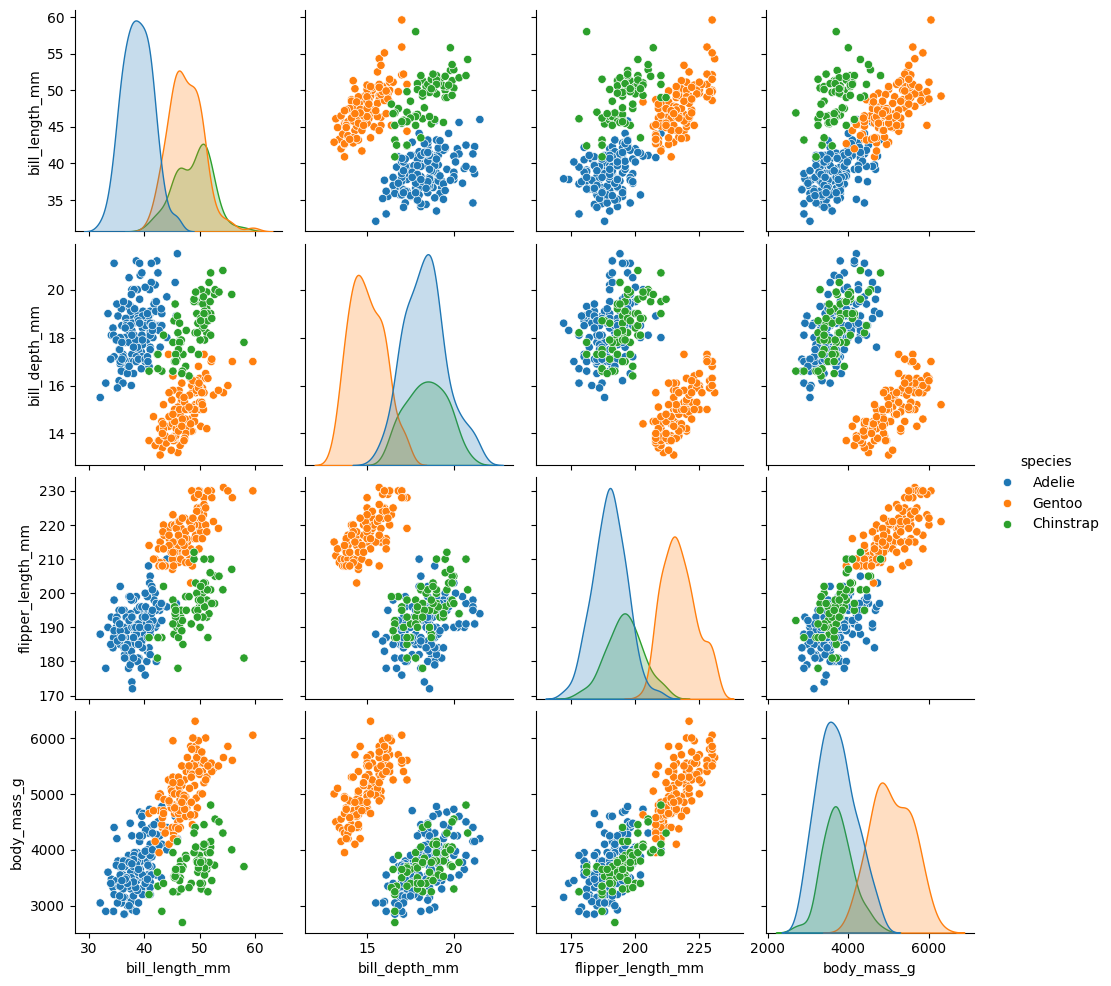

In [8]:
display(df.head(10))
display(df.describe(include="all").T)

print("\nSpecies counts:")
print(df["species"].value_counts(dropna=False))


sns.pairplot(
    df.dropna(subset=["species"]),
    hue="species",
    vars=[c for c in df.select_dtypes(include="number").columns if c != "year"][:4]
)
plt.show()

**Q2**: Which columns contain missing values? What strategy will you use to handle them?

In [9]:
# Missing values
na_counts = df.isna().sum().sort_values(ascending=False)
display(na_counts[na_counts > 0])

# Strategy for this assignment: drop rows with any missing values
df_clean = df.dropna().copy()
print("Before:", df.shape, " After dropna:", df_clean.shape)

sex                  11
bill_depth_mm         2
flipper_length_mm     2
bill_length_mm        2
body_mass_g           2
dtype: int64

Before: (344, 8)  After dropna: (333, 8)


**Q3**: Is the dataset balanced across the three species?

In [ ]:
df['species'].value_counts()
# -> The dataset of `Chinstrap` data is a bit lacking,compared to the others

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

#### 3) Data Cleaning & Encoding

* We’ll keep only rows with complete values for simplicity.

In [ ]:
df_clean = df.dropna().copy()

**Q4**: Why don’t we need to scale features for Decision Trees?

We don’t need to scale features for Decision Trees because they split data using feature thresholds and depend on the ordering of values within each feature. A linear scaling of a feature does not change the relative order of samples, so the chosen splits and the final tree are essentially unchanged.

#### 4) Train/Test Split

In [11]:
# Target
y = df_clean["species"].astype(str)

# Baseline features: numeric-only 
X_num = df_clean.select_dtypes(include="number").copy()

print("X_num shape:", X_num.shape)
print("y shape:", y.shape)
X_num.head()

# Encode target labels to integers for sklearn
le = LabelEncoder()
y_enc = le.fit_transform(y)

print("Classes:", list(le.classes_))
print("Encoded label sample:", y_enc[:10])

feature_names_num = X_num.columns.tolist()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_num, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc  # keep class proportions similar in train/test
)

print("Train:", X_train.shape, "Test:", X_test.shape)

X_num shape: (333, 5)
y shape: (333,)
Classes: ['Adelie', 'Chinstrap', 'Gentoo']
Encoded label sample: [0 0 0 0 0 0 0 0 0 0]
Train: (266, 5) Test: (67, 5)


**Q5**: Why do we use stratify=y in this split?

We use stratify=y to keep the class proportions in the training and test sets as similar as possible to the original dataset. This helps prevent a class from being underrepresented in the test set, which would make evaluation unstable or biased.

#### 5) Baseline Decision Tree

Baseline test accuracy: 0.9552238805970149

Classification report:
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        29
   Chinstrap       0.88      1.00      0.93        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.95      0.96      0.95        67
weighted avg       0.96      0.96      0.96        67



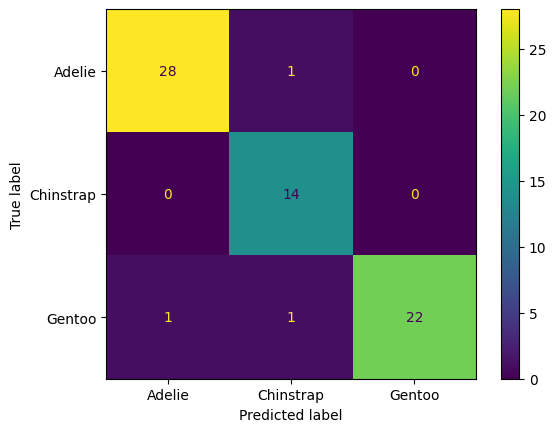

In [12]:
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)

y_pred = dt_base.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Baseline test accuracy:", acc)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
plt.show()

**Q6**: Which classes are the most/least confounded? What might cause that?

Most confounded class: Gentoo
Least confounded class: Chinstrap

Causes:\
**Small sample size in test set:** With only a few dozen samples per class, 1–2 borderline points can noticeably affect the confusion matrix.\
**Model simplicity -> missing informative features:** Because of only using numeric features, not including variables like `island` `sex`, the tree may lack extra signals to separate tricky cases, leading to a few mix-ups.

#### 6) Visualize the Tree

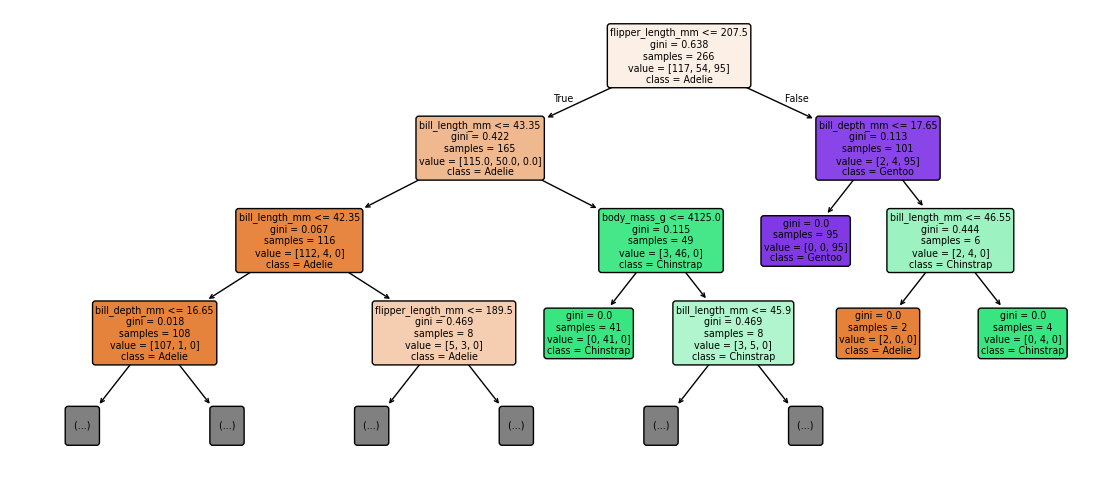

Root split feature: flipper_length_mm
Root split threshold: 207.5


In [ ]:
plt.figure(figsize=(14, 6))
plot_tree(
    dt_base,
    feature_names=feature_names_num,
    class_names=le.classes_,
    filled=True,
    max_depth=3,
    rounded=True
)
plt.show()



**Q7**: What is the root split (feature and threshold)? Why do you think the algorithm chose it?

In [16]:
root_feature_idx = dt_base.tree_.feature[0]
root_feature = feature_names_num[root_feature_idx] if root_feature_idx != -2 else None
print("Root split feature:", root_feature)

root_threshold = dt_base.tree_.threshold[0]
print("Root split threshold:", root_threshold)

print("\nWhy do you think the algorithm chose it?\nBecause it is the feature that yields the largest information gain and greatest reduction in Gini impurity.")

Root split feature: flipper_length_mm
Root split threshold: 207.5

Why do you think the algorithm chose it?
Because it is the feature that yields the largest information gain and greatest reduction in Gini impurity.


#### 7) Decision Boundaries (2D View)
* Pick two features (e.g., bill_length_mm vs bill_depth_mm) and visualize the decision surface.

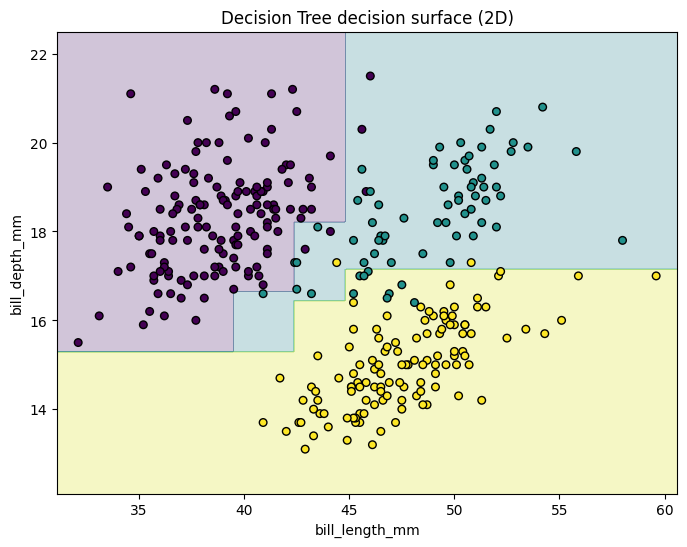

2D test accuracy: 0.9104477611940298


In [18]:
# Pick two numeric features to visualize
f1, f2 = "bill_length_mm", "bill_depth_mm"

if f1 not in X_num.columns or f2 not in X_num.columns:
    raise ValueError(f"Features {f1}, {f2} not found. Available: {list(X_num.columns)}")

X_2d = df_clean[[f1, f2]].copy()
y_2d = y_enc

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d, y_2d, test_size=0.2, random_state=42, stratify=y_2d
)

dt_2d = DecisionTreeClassifier(random_state=42, max_depth=4)
dt_2d.fit(X2_train, y2_train)

# Mesh grid
x_min, x_max = X_2d[f1].min() - 1, X_2d[f1].max() + 1
y_min, y_max = X_2d[f2].min() - 1, X_2d[f2].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_df = pd.DataFrame(grid, columns=[f1, f2])

Z = dt_2d.predict(grid_df).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25)
scatter = plt.scatter(X_2d[f1], X_2d[f2], c=y_2d, edgecolor="k", s=30)
plt.xlabel(f1)
plt.ylabel(f2)
plt.title("Decision Tree decision surface (2D)")
plt.show()

print("2D test accuracy:", accuracy_score(y2_test, dt_2d.predict(X2_test)))


**Q8**: Do the boundaries look axis-aligned? Why is that a natural property of Decision Trees?

Yes. The boundaries are axis-aligned because a standard Decision Tree makes splits of the form feature ≤ threshold on one feature at a time. In a 2D plot, splitting on x creates a vertical line and splitting on y creates a horizontal line, so the resulting regions are rectangles.

#### 8) Hyperparameter Tuning with GridSearchCV

In [19]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy", "log_loss"],
}

dt = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

best_dt = grid.best_estimator_
y_pred_best = best_dt.predict(X_test)
print("Tuned test accuracy:", accuracy_score(y_test, y_pred_best))

Best params: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV accuracy: 0.969811320754717
Tuned test accuracy: 0.9552238805970149


**Q9**: Which hyperparameters changed compared to the baseline? How did test accuracy change?

**Q10**: If CV accuracy is much higher than test accuracy, what could be happening?

**Q9:** Compared to the baseline, GridSearch can change max_depth, min_samples_split, min_samples_leaf, and criterion whichever appear in `best_params_`. Test accuracy changes from the baseline accuracy to the printed “Tuned test accuracy”, it drops.

**Q10:** If CV accuracy is much higher than test accuracy, it likely indicates overfitting, or high variance caused by a smmall dataset or a train–test distribution mismatch.

#### 9) Model Interpretation

flipper_length_mm    0.549353
bill_length_mm       0.369690
bill_depth_mm        0.069747
body_mass_g          0.011211
year                 0.000000
dtype: float64

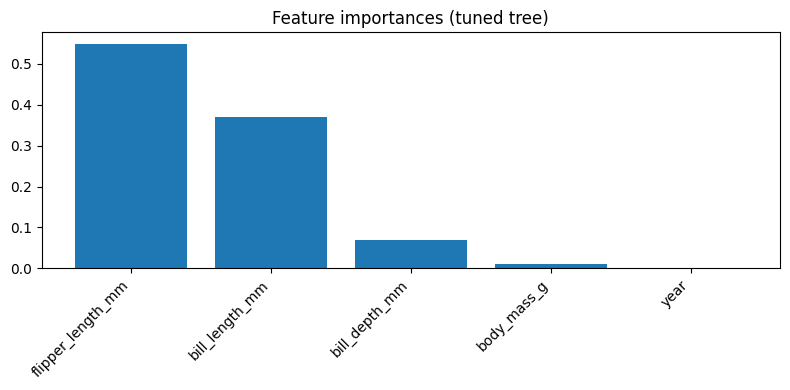

Sample index: 0
True: Gentoo
Pred: Gentoo
Probabilities: {'Adelie': np.float64(0.0), 'Chinstrap': np.float64(0.0), 'Gentoo': np.float64(1.0)}


In [20]:
# Feature importances
importances = pd.Series(best_dt.feature_importances_, index=feature_names_num).sort_values(ascending=False)
display(importances)

plt.figure(figsize=(8, 4))
plt.bar(importances.index, importances.values)
plt.xticks(rotation=45, ha="right")
plt.title("Feature importances (tuned tree)")
plt.tight_layout()
plt.show()

# Inspect one sample prediction probability
i = 0
x_one = X_test.iloc[[i]]
true_label = le.inverse_transform([y_test[i]])[0]
pred_proba = best_dt.predict_proba(x_one)[0]
pred_label = le.inverse_transform([best_dt.predict(x_one)[0]])[0]

print("Sample index:", i)
print("True:", true_label)
print("Pred:", pred_label)
print("Probabilities:", dict(zip(le.classes_, pred_proba)))

**Q11**: Which feature is most important? Is that consistent with your EDA intuition?

**Q12**: For the inspected sample, does the class probability look confident? Why/why not?

**Q11:** The most important feature is flipper_length_mm (importance ≈ 0.55), followed by bill_length_mm (≈ 0.37). This is consistent with EDA intuition: the species are well separated by flipper length and by bill length.

**Q12:** For the inspected sample, the predicted probabilities are very confident: {'Gentoo': 1.0, 'Adelie': 0.0, 'Chinstrap': 0.0}. This indicates the sample falls into a leaf node that is almost pure Gentoo, so the model assigns a 100% probability to Gentoo.

#### 10) (Optional) Add Categorical Features & Compare

In [21]:
# Use both numeric + categorical features with one-hot encoding
if "df_clean" not in globals():
    df_clean = df.dropna().copy()

y_all = df_clean["species"].astype(str)
le2 = LabelEncoder()
y_all_enc = le2.fit_transform(y_all)

X_all = df_clean.drop(columns=["species"]).copy()

cat_cols = X_all.select_dtypes(exclude="number").columns.tolist()
num_cols = X_all.select_dtypes(include="number").columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

pipe = Pipeline(steps=[
    ("preprocess", pre),
    ("model", DecisionTreeClassifier(random_state=42))
])

Xtr, Xte, ytr, yte = train_test_split(
    X_all, y_all_enc, test_size=0.2, random_state=42, stratify=y_all_enc
)

pipe.fit(Xtr, ytr)
yhat = pipe.predict(Xte)
print("With categorical features (one-hot) test accuracy:", accuracy_score(yte, yhat))

# tune again in this pipeline
param_grid2 = {
    "model__max_depth": [3, 4, 5, 6, None],
    "model__min_samples_leaf": [1, 2, 4, 8],
}
grid2 = GridSearchCV(pipe, param_grid=param_grid2, cv=5, scoring="accuracy", n_jobs=-1)
grid2.fit(Xtr, ytr)
print("Best params (with cats):", grid2.best_params_)
print("Best CV accuracy (with cats):", grid2.best_score_)
print("Best tuned test accuracy (with cats):", accuracy_score(yte, grid2.best_estimator_.predict(Xte)))

With categorical features (one-hot) test accuracy: 0.9701492537313433
Best params (with cats): {'model__max_depth': 5, 'model__min_samples_leaf': 2}
Best CV accuracy (with cats): 0.9849056603773585
Best tuned test accuracy (with cats): 0.9701492537313433


**Q13**: Did adding island/sex help? Why might these variables be informative for species?

Yes.

**Results:**\
Best CV accuracy: 0.969811320754717 -> 0.9849056603773585\
Tuned test accuracy: 0.9552238805970149 -> 0.9701492537313433

Because `island` and `sex` may be correlated with species distribution: different species tend to inhabit different islands; and sex is related to body size (e.g., `body mass` `flipper length`), which can indirectly help classification.

#### 11) Reflection & Reporting

Write a short reflection (5–10 lines):
- Compare Decision Tree vs KNN on this dataset.
-  Where does the tree overfit? How did pruning/tuning impact generalization?
- Which 2D feature pair gave the clearest separation? Why?

On this penguins dataset, a Decision Tree works well with almost no preprocessing and is easy to interpret via splits like the root split on flipper_length_mm.
KNN, in contrast, typically needs feature scaling and is sensitive to the choice of k; it tends to produce smoother, distance-based boundaries rather than rule-based splits.


A tree can overfit when it grows too deep and creates many small, axis-aligned “pockets” that fit noise or borderline points.
In my run, pruning selected a simpler tree (**max_depth=4, min_samples_leaf=2**), which controls complexity; test accuracy stayed strong (baseline 0.955 → tuned 0.955) while CV accuracy was high (~0.970).


Based on feature importances, also combining the exported plot of EDA, the clearest 2D separation should come from `flipper_length_mm` and `bill_length_mm`.
They rank highest because they reduce impurity the most: flipper length strongly separates species with different body size, and bill length further separates species with similar flipper lengths, so together they provide strong discriminative power.